## Step 1 : Data Exploration (DataSet1)

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import cv2
from PIL import Image
import numpy as np

In [2]:
DATASET_PATH = "/kaggle/input/competitions/deepfake-detection-challenge"

In [3]:
# 1. Lister les vidéos
train_videos = os.listdir(os.path.join(DATASET_PATH, "train_sample_videos"))
print(f"Nombre de vidéos dans train_sample_videos : {len(train_videos)}")

Nombre de vidéos dans train_sample_videos : 401


In [4]:
# 2. Charger le metadata.json (c'est le fichier qui contient les labels)
metadata_path = os.path.join(DATASET_PATH, "train_sample_videos", "metadata.json")
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

In [5]:
# 3. Créer un DataFrame
data = []
for video, info in metadata.items():
    data.append({
        'video': video,
        'label': info['label'],
        'original': info.get('original', None)
    })

df = pd.DataFrame(data)
print(f"\nTotal vidéos avec labels : {len(df)}")
print(df['label'].value_counts())


Total vidéos avec labels : 400
label
FAKE    323
REAL     77
Name: count, dtype: int64


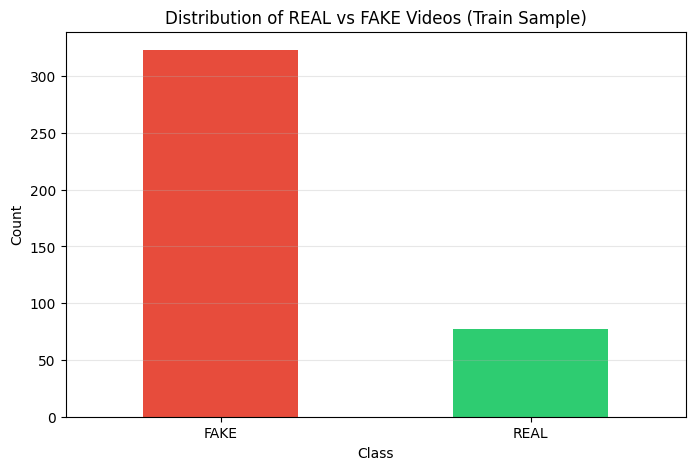

In [6]:
# 4. Graphique de balance
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Distribution of REAL vs FAKE Videos (Train Sample)')
plt.ylabel('Count')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

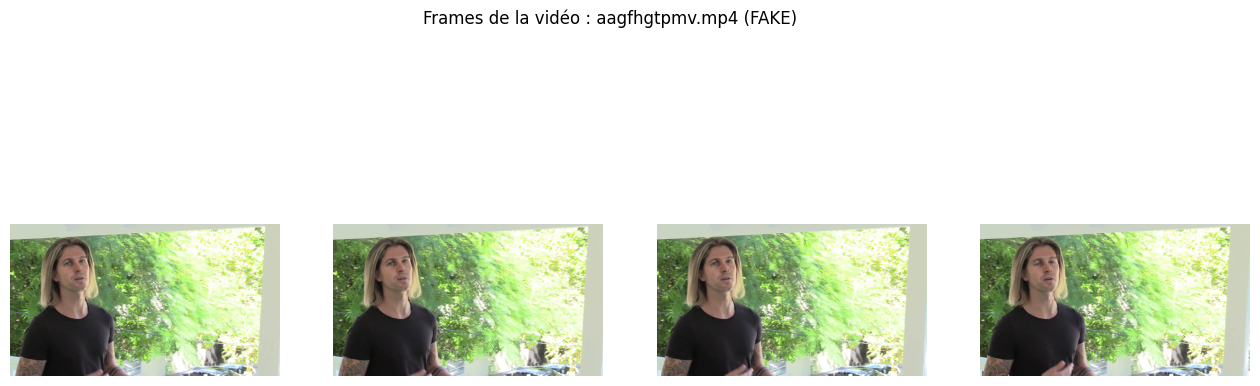

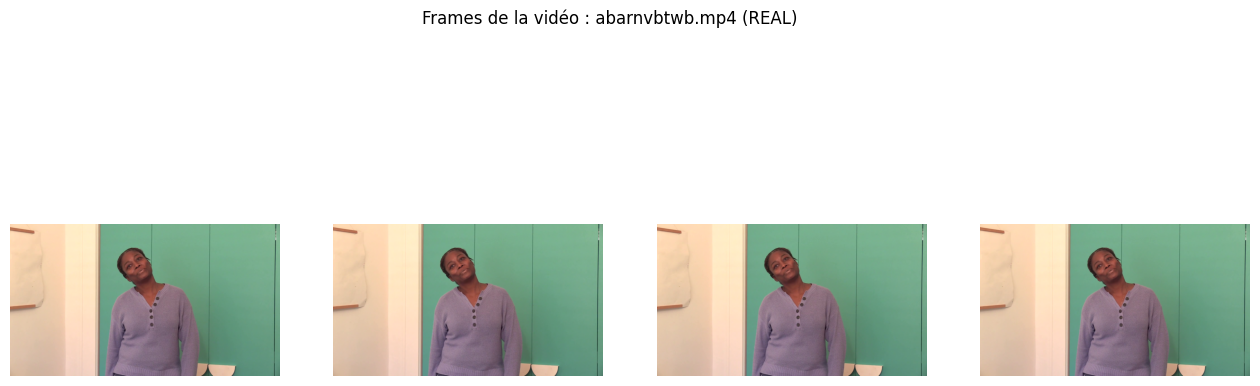

In [7]:
# 5. Affichage de quelques frames d'une vidéo (pour vérifier)
def show_video_frames(video_name, n_frames=4):
    video_path = os.path.join(DATASET_PATH, "train_sample_videos", video_name)
    cap = cv2.VideoCapture(video_path)
    frames = []
    for i in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    
    plt.figure(figsize=(16, 6))
    for i, frame in enumerate(frames):
        plt.subplot(1, n_frames, i+1)
        plt.imshow(frame)
        plt.axis('off')
    plt.suptitle(f"Frames de la vidéo : {video_name} ({df[df['video']==video_name]['label'].values[0]})")
    plt.show()

# Exemples
show_video_frames(df[df['label']=='FAKE'].iloc[0]['video'])
show_video_frames(df[df['label']=='REAL'].iloc[0]['video'])

## Step 2: Data Preparation

In [8]:
import os
import json
import pandas as pd
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
from PIL import Image
from collections import Counter

In [9]:
DATASET_PATH = "/kaggle/input/competitions/deepfake-detection-challenge"

In [10]:
# Chargement du metadata
metadata_path = os.path.join(DATASET_PATH, "train_sample_videos", "metadata.json")
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

In [11]:
# Création du DataFrame
data = []
for video, info in metadata.items():
    data.append({
        'video': video,
        'label': 1 if info['label'] == 'FAKE' else 0,   # 1 = FAKE, 0 = REAL
        'original': info.get('original', None)
    })

df = pd.DataFrame(data)
print(f"Total vidéos : {len(df)}")
print("Distribution :", Counter(df['label']))

Total vidéos : 400
Distribution : Counter({1: 323, 0: 77})


In [12]:
# ====================== TRANSFORMS POUR LES FRAMES ======================
frame_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [13]:
# ====================== CUSTOM DATASET (extraction de frames) ======================
class DeepfakeVideoDataset(Dataset):
    def __init__(self, df, root_dir, num_frames=8, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        video_name = self.df.iloc[idx]['video']
        label = self.df.iloc[idx]['label']
        video_path = os.path.join(self.root_dir, "train_sample_videos", video_name)
        
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step = max(1, total_frames // self.num_frames)
        
        for i in range(0, total_frames, step):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
            if len(frames) >= self.num_frames:
                break
        cap.release()
        
        # Si moins de frames, on duplique la dernière
        while len(frames) < self.num_frames:
            frames.append(frames[-1])
        
        # On prend exactement num_frames frames
        frames = torch.stack(frames[:self.num_frames])
        return frames, torch.tensor(label, dtype=torch.long)

In [14]:
# Création du Dataset
video_dataset = DeepfakeVideoDataset(df, DATASET_PATH, num_frames=8, transform=frame_transform)

batch_size = 4   # petit batch car vidéos = beaucoup de mémoire
video_loader = DataLoader(video_dataset, batch_size=batch_size, shuffle=True, 
                          num_workers=2, pin_memory=True)

print(f"\n Video Dataset créé : {len(video_dataset)} vidéos")
print(f" DataLoader prêt (batch_size={batch_size}, {len(video_loader)} batches)")
print("Chaque batch contient 8 frames par vidéo → shape : (batch, 8, 3, 224, 224)")

# Test rapide d'un batch
frames, labels = next(iter(video_loader))
print(f"Shape d'un batch : {frames.shape} | Labels : {labels.shape}")


 Video Dataset créé : 400 vidéos
 DataLoader prêt (batch_size=4, 100 batches)
Chaque batch contient 8 frames par vidéo → shape : (batch, 8, 3, 224, 224)
Shape d'un batch : torch.Size([4, 8, 3, 224, 224]) | Labels : torch.Size([4])


## MTCNN bib install

In [15]:
!pip install mtcnn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.4 MB/s eta 0:00:00


# Step 3 : Feature Extraction + Classification

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
from mtcnn import MTCNN
from PIL import Image
import numpy as np

2026-04-15 20:07:58.611624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776283678.798800      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776283678.855131      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776283679.333513      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776283679.333558      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776283679.333561      55 computation_placer.cc:177] computation placer alr

In [17]:
# Initialisation du détecteur de visages (MTCNN est léger et performant sur Kaggle)
detector = MTCNN()

# Transform pour les visages cropped
face_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class DeepfakeFaceVideoDataset(Dataset):
    def __init__(self, df, root_dir, num_frames=8, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.transform = transform
        self.detector = MTCNN()
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        video_name = self.df.iloc[idx]['video']
        label = self.df.iloc[idx]['label']
        video_path = os.path.join(self.root_dir, "train_sample_videos", video_name)
        
        cap = cv2.VideoCapture(video_path)
        faces = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step = max(1, total_frames // self.num_frames)
        
        for i in range(0, total_frames, step):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                break
            
            # Détection de visage
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.detector.detect_faces(rgb_frame)
            
            if results:
                # Prendre le visage le plus grand (le plus probable)
                face = max(results, key=lambda x: x['box'][2] * x['box'][3])
                x, y, w, h = face['box']
                face_crop = rgb_frame[y:y+h, x:x+w]
                face_crop = Image.fromarray(face_crop)
                if self.transform:
                    face_crop = self.transform(face_crop)
                faces.append(face_crop)
            
            if len(faces) >= self.num_frames:
                break
        cap.release()
        
        # Si pas assez de visages détectés, on duplique le dernier
        while len(faces) < self.num_frames:
            if faces:
                faces.append(faces[-1])
            else:
                # Cas rare : aucune face détectée → on met un tensor noir
                faces.append(torch.zeros(3, 224, 224))
        
        faces = torch.stack(faces[:self.num_frames])
        return faces, torch.tensor(label, dtype=torch.long)

I0000 00:00:1776283697.566784      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776283697.573444      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [18]:
# ====================== CRÉATION DU DATASET AVEC FACES ======================
face_video_dataset = DeepfakeFaceVideoDataset(df, DATASET_PATH, num_frames=4, transform=face_transform)

# IMPORTANT : num_workers=0 pour éviter l'erreur CUDA sur Kaggle
batch_size = 4

face_video_loader = DataLoader(
    face_video_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0,          # ← CHANGEMENT IMPORTANT
    pin_memory=True
)

print(f"\n Face Video Dataset créé : {len(face_video_dataset)} vidéos")
print(f" DataLoader prêt (batch_size={batch_size}, num_workers=0)")

# Test rapide d'un batch
faces_batch, labels = next(iter(face_video_loader))
print(f"Shape d'un batch de visages : {faces_batch.shape}")


 Face Video Dataset créé : 400 vidéos
 DataLoader prêt (batch_size=4, num_workers=0)
Shape d'un batch de visages : torch.Size([4, 4, 3, 224, 224])


# Step 4 : Model from Scratch + Entraînement (sur visages extraits des vidéos)

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## les couches du modèle

In [21]:
# ====================== 1. Modèle from Scratch pour vidéos ======================
class BaseVideoCNN(nn.Module):
    def __init__(self):
        super(BaseVideoCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # réduit chaque frame à un vecteur
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)          # 0 = REAL, 1 = FAKE
        )
    
    def forward(self, x):
        # x shape: (batch, num_frames, 3, 224, 224)
        batch, num_frames, C, H, W = x.shape
        x = x.view(batch * num_frames, C, H, W)   # traiter chaque frame indépendamment
        x = self.cnn(x)
        x = self.classifier(x)
        x = x.view(batch, num_frames, 2)
        x = x.mean(dim=1)   # moyenne des prédictions sur les frames
        return x

model_video = BaseVideoCNN().to(device)

In [22]:
# ====================== 2. Gestion du déséquilibre (class weights) ======================
class_counts = Counter(df['label'])
weights = [1.0 / class_counts[0], 1.0 / class_counts[1]]
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_video.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [23]:
# ====================== 3. Entraînement ======================
num_epochs = 5
print(f"\n Entraînement Model from Scratch sur vidéos deepfake ({num_epochs} epochs)")

for epoch in range(num_epochs):
    model_video.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(face_video_loader, desc=f"Epoch {epoch+1}")
    
    for faces_batch, labels in pbar:
        faces_batch, labels = faces_batch.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_video(faces_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix(loss=running_loss/len(face_video_loader), acc=100.*correct/total)
    
    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} → Loss: {running_loss/len(face_video_loader):.4f} | Accuracy: {100.*correct/total:.2f}%")

# ====================== 4. Sauvegarde ======================
torch.save(model_video.state_dict(), "/kaggle/working/base_cnn_video_deepfake.pth")
print("\n Modèle from Scratch (vidéos) sauvegardé avec succès !")


 Entraînement Model from Scratch sur vidéos deepfake (5 epochs)


Epoch 1: 100%|██████████| 100/100 [49:24<00:00, 29.65s/it, acc=79, loss=0.697]  


Epoch 1/5 → Loss: 0.6973 | Accuracy: 79.00%


Epoch 2: 100%|██████████| 100/100 [48:39<00:00, 29.19s/it, acc=80.8, loss=0.674]


Epoch 2/5 → Loss: 0.6738 | Accuracy: 80.75%


...

Epoch 3/5 → Loss: 0.6694 | Accuracy: 80.75%


Epoch 4: 100%|██████████| 100/100 [47:30<00:00, 28.51s/it, acc=80.8, loss=0.673]


Epoch 4/5 → Loss: 0.6732 | Accuracy: 80.75%


Epoch 5: 100%|██████████| 100/100 [48:04<00:00, 28.84s/it, acc=80.8, loss=0.657]

Epoch 5/5 → Loss: 0.6566 | Accuracy: 80.75%

 Modèle from Scratch (vidéos) sauvegardé avec succès !
